In [1]:
import os
import numpy as np
import astropy.io.fits as pyfits
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from tqdm import tqdm
import zipfile

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torch.optim import Adam
from torch.optim.lr_scheduler import MultiStepLR
import torchvision.transforms.functional as TF

In [2]:
seed = 42
torch.manual_seed(seed)

EVALUATION = False
DATA_DIR = "/bohr/training-lg02/v1/" if EVALUATION else "/home/stefan/ioai-prep/kits/ioai-2025/dark-matter"

DEVICE = "cuda"
MODEL_SAVE_PATH = "model.pth"

BATCH_SIZE = 1
ACCUMULTATION_STEPS = 8

SMOOTHING = 3 # parameter for Gaussian Smoothing 

# Data processing

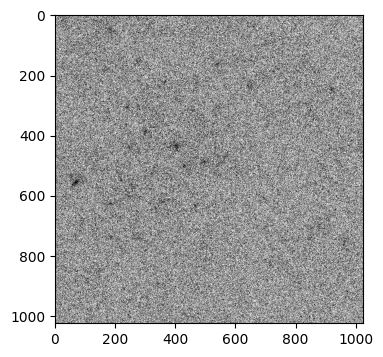

In [3]:
# Show raw convergence map
Z = pyfits.open(os.path.join(DATA_DIR, 'map/1.fits'))[0].data
plt.figure(figsize=(5, 4))
plt.imshow(Z, vmin=-0.1, vmax=0.2, cmap='binary')
plt.show()

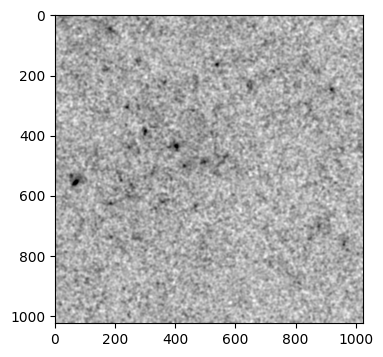

In [4]:
# Apply Gaussian Smoothing
Z_smooth = gaussian_filter(Z, sigma=SMOOTHING)
plt.figure(figsize=(5, 4))
plt.imshow(Z_smooth, vmin=-0.1, vmax=0.2, cmap='binary')
plt.show()

In [5]:
# Read halo labels
cat1 = pyfits.open(os.path.join(DATA_DIR, 'cat/1.fits'))[0].data
cat1.shape

(125, 3)

# Dataset

In [6]:
class AstroDataset(Dataset):
    def __init__(self, map_paths, cat_paths=None):
        self.map_paths = map_paths
        self.cat_paths = cat_paths
    
    def __len__(self):
        return len(self.map_paths)
    
    def __getitem__(self, idx):
        # Load image with gaussian smoothing
        map_data = gaussian_filter(pyfits.open(self.map_paths[idx])[0].data, sigma=SMOOTHING)
        
        if self.cat_paths is None:
            return torch.FloatTensor(map_data).unsqueeze(0)

        # Load catalog
        cat = pyfits.open(self.cat_paths[idx])[0].data
        target = np.zeros((1024, 1024))

        for y, x in cat[:, 1:3]:
            target[int(y), int(x)] = 1.0

        return torch.FloatTensor(map_data).unsqueeze(0), torch.FloatTensor(target), self.cat_paths[idx]

In [7]:
map_files = sorted([os.path.join(DATA_DIR, 'map', f) for f in os.listdir(os.path.join(DATA_DIR, 'map')) if f.endswith('.fits')])
cat_files = sorted([os.path.join(DATA_DIR, 'cat', f) for f in os.listdir(os.path.join(DATA_DIR, 'cat')) if f.endswith('.fits')])

dataset = AstroDataset(map_files, cat_files)

data_size = len(dataset)
train_size = int(0.8 * data_size)
test_size = data_size - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Total dataset size: {data_size}")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")

# Create data loaders for training and testing
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Total dataset size: 70
Training dataset size: 56
Testing dataset size: 14


In [8]:
# sanity check
batch = next(iter(train_dataloader))
[b.shape for b in batch if not isinstance(b, tuple)]

[torch.Size([1, 1, 1024, 1024]), torch.Size([1, 1024, 1024])]

# Model

In [9]:
class ImprovedResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ImprovedResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout2d(0.5)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out

In [10]:
class Model(nn.Module):
    def __init__(self, num_classes=1):
        super(Model, self).__init__()
        
        self.encoder_conv1 = nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2, bias=False)
        self.encoder_bn1 = nn.BatchNorm2d(32)
        self.encoder_relu = nn.LeakyReLU()
        
        self.layer1 = ImprovedResidualBlock(32, 64, stride=2)  # 512x512
        self.layer2 = ImprovedResidualBlock(64, 128, stride=2) # 256x256
        
        self.deconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.deconv1_bn = nn.BatchNorm2d(64)
        self.deconv1_relu = nn.LeakyReLU()
        
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.deconv2_bn = nn.BatchNorm2d(32)
        self.deconv2_relu = nn.LeakyReLU()
        
        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.encoder_conv1(x)
        x1 = self.encoder_bn1(x1)
        x1 = self.encoder_relu(x1)
        
        x2 = self.layer1(x1)  # 512x512
        x3 = self.layer2(x2)  # 256x256
        
        x4 = self.deconv1(x3)  # 512x512
        x4 = self.deconv1_bn(x4)
        x4 = self.deconv1_relu(x4)
        x4 = x4 + x2
        
        x5 = self.deconv2(x4) # 1024x1024
        x5 = self.deconv2_bn(x5)
        x5 = self.deconv2_relu(x5)
        x5 = x5 + x1
        
        x = self.final_conv(x5)
        return x

In [11]:
model = Model().to(DEVICE)

x = batch[0].to(DEVICE)
model(x).shape

torch.Size([1, 1, 1024, 1024])

# Training

In [12]:
# Function for applicating model results
def detect_objects(model, image_path, confidence_threshold, device=DEVICE):
    model.eval()
    with torch.no_grad():
        # Load and preprocess image
        map_data = gaussian_filter(pyfits.open(image_path)[0].data, sigma=SMOOTHING)
        image = torch.FloatTensor(map_data).unsqueeze(0).unsqueeze(0).to(device)
        
        # Get predictions
        output = torch.sigmoid(model(image))
        predictions = output.cpu().squeeze().numpy()
        
        # Convert to coordinates
        coordinates = []
        for y, x in zip(*np.where(predictions > confidence_threshold)):
            confidence = predictions[y, x]
            coordinates.append((x, y, confidence))
            
        return coordinates

# Visualizing model predictions
def visualize_results(model, image_path, label_path, confidence_threshold, device=DEVICE):
    # Get predictions with confidence scores
    results = detect_objects(model, image_path, confidence_threshold, device)
    results = np.array(results).T if results else np.array([[],[],[]])
    
    Z = pyfits.open(image_path)[0].data
    Z_smooth = gaussian_filter(Z, sigma=SMOOTHING)
    
    labels = np.transpose(pyfits.open(label_path)[0].data)
    
    plt.figure(figsize=(10,10))
    plt.imshow(Z_smooth, vmin=-0.1, vmax=0.2, cmap='binary')
    plt.scatter(labels[2], labels[1], facecolors='none', edgecolors='red', s=100, label="True")
    if len(results[0]) > 0:
        # Color the scatter points based on confidence scores
        plt.scatter(results[0], results[1], facecolors='none', edgecolors='green', s=100, label="Predicted")
    plt.legend()
    plt.show()


'''
Metric function for calculating PR-AUC.
This exact function will be used for evaluation
'''
def calculate_precision_recall_curve(predictions, labels):

    print("shape of predictions: ", predictions.shape)

    # Flatten the predictions and get the indices of the sorted predictions
    flat_predictions = predictions.flatten()
    sorted_indices = np.argsort(-flat_predictions)  # Sort in descending order

    precisions = []
    recalls = []

    true_preds = 0
    num_preds = 0
    predicted_labels = 0
    num_labels = sum(len(l) for l in labels)

    labels_within_distance = [[] for _ in range(len(flat_predictions))]

    i = 0
    for image_idx, image_labels in enumerate(labels):
        for y_true, x_true in image_labels:
            for y in range(max(0, int(y_true) - 15), min(1024, int(y_true) + 16)):
                # Calculate the maximum x distance for the current y
                max_x_dist = int((max(0, 15**2 - (y - y_true)**2))**0.5)
                # Calculate the range of x-coordinates
                for x in range(max(0, int(x_true) - max_x_dist), min(1024, int(x_true) + max_x_dist + 1)):
                    coord_idx = image_idx * 1024 * 1024 + y * 1024 + x
                    labels_within_distance[coord_idx].append(i)
            i += 1
    
    label_predicted = [False] * num_labels

    # Iterate over sorted predictions
    for idx in sorted_indices:

        num_preds += 1

        # Determine the image index and the coordinate within the image
        image_idx = idx // (1024 * 1024)
        coord_idx = idx % (1024 * 1024)
        y, x = divmod(coord_idx, 1024)

        if len(labels_within_distance[idx]) > 0:
            true_preds += 1
            for label in labels_within_distance[idx]:
                if label_predicted[label] is False:
                    label_predicted[label] = True
                    predicted_labels += 1

        # Calculate precision and recall
        precision = true_preds / num_preds
        recall = predicted_labels / num_labels

        # Append precision and recall to the lists
        precisions.append(precision)
        recalls.append(recall)

    # Calculate PR-AUC using the trapezoidal rule
    pr_auc = np.trapz(precisions, x=recalls)

    return precisions, recalls, pr_auc

def tta_predict(model, images, device):
    """
    images: Tensor of shape (B,1,H,W)
    returns: numpy array (B,H,W) of averaged probabilities
    """
    # List of (apply_fn, inverse_fn) for flips
    tta_transforms = [
        (lambda x: x,                  lambda x: x),
        (lambda x: torch.flip(x, [3]), lambda x: torch.flip(x, [3])),  # horiz
        (lambda x: torch.flip(x, [2]), lambda x: torch.flip(x, [2])),  # vert
        (lambda x: torch.flip(x, [2,3]), lambda x: torch.flip(x, [2,3])),  # both
    ]
    preds = []
    with torch.no_grad():
        for apply_fn, inv_fn in tta_transforms:
            x_t = apply_fn(images)
            logits = model(x_t.to(device))            # B×1×H×W logits
            prob   = torch.sigmoid(logits)            # B×1×H×W
            prob   = inv_fn(prob)                     # invert flip
            preds.append(prob.cpu())
    # stack over TTA dimension and average
    # result: (T, B, 1, H, W) → mean → (B, 1, H, W)
    mean_pred = torch.stack(preds, dim=0).mean(dim=0)
    # drop channel dim → (B, H, W)
    return mean_pred.squeeze(1).numpy()

# Evaluate model
def get_pr(model, test_loader, device=DEVICE):
    model.eval()
    for images, _, paths in test_loader:
        with torch.no_grad():
            images = images.to(device)
            logits = model(images)
            outputs = (torch.sigmoid(logits)).cpu().numpy().squeeze(1)
            cat_data = [np.transpose(pyfits.open(path)[0].data) for path in paths]
            labels = [list(zip(cat[1], cat[2])) for cat in cat_data]
        return calculate_precision_recall_curve(outputs, labels)

In [13]:
NUM_EPOCHS = 1
LEARNING_RATE = 1e-2

In [14]:
def train(model, best_pr = 0):
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(1e12, device=DEVICE))
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

    train_losses = []

    optimizer.zero_grad()

    for epoch in range(NUM_EPOCHS):
        model.train()
        total_loss, test_loss = 0, 0
        
        for i, (images, targets, _) in enumerate(tqdm(train_dataloader)):
            images, targets = images.to(DEVICE), targets.to(DEVICE)

            # forward pass
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, targets)
            loss = loss / ACCUMULTATION_STEPS

            if torch.isnan(loss):
                print("NAN LOSS")
                break

            # backward pass
            loss.backward()

            if (i + 1) % ACCUMULTATION_STEPS == 0:
                optimizer.step()
                optimizer.zero_grad()

            # stats
            total_loss += loss.item() * ACCUMULTATION_STEPS
            train_losses.append(loss.item() * ACCUMULTATION_STEPS)

        model.eval()
        with torch.no_grad():
            for images, targets, _ in tqdm(test_dataloader):
                images, targets = images.to(DEVICE), targets.to(DEVICE)
                outputs = model(images).squeeze(1)
                loss = criterion(outputs, targets)
                test_loss += loss.item()
        
        train_loss = total_loss/len(train_dataloader)
        test_loss = test_loss/len(test_dataloader)
        _, _, pr_auc = get_pr(model, test_dataloader)

        # scheduler.step(train_loss)

        if pr_auc > best_pr:
            best_pr = pr_auc
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print("Saved new best model...")

        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}]; train_loss={train_loss:.4f}; test_loss={test_loss:.4f}; pr_auc={pr_auc:.4f}')
    return train_losses, best_pr

In [15]:
best_pr = 0
ckpts, val_scores = [], []

for i in range(5):
    new_model = Model().to(DEVICE)
    train_losses, best_pr = train(new_model)

    ckpts.append(f"{i}.pth")
    torch.save(new_model.state_dict(), f"{i}.pth")
    val_scores.append(best_pr)

100%|██████████| 14/14 [00:01<00:00, 13.06it/s]


shape of predictions:  (1, 1024, 1024)


/tmp/ipykernel_20650/727577447.py:104: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_auc = np.trapz(precisions, x=recalls)


Saved new best model...
Epoch [1/1]; train_loss=14948445.3571; test_loss=5409875.3571; pr_auc=0.6745


100%|██████████| 14/14 [00:01<00:00, 13.10it/s]


...

shape of predictions:  (1, 1024, 1024)
Saved new best model...
Epoch [1/1]; train_loss=48173940.1250; test_loss=16437311.0714; pr_auc=0.6405


100%|██████████| 14/14 [00:01<00:00, 13.71it/s]


shape of predictions:  (1, 1024, 1024)
Saved new best model...
Epoch [1/1]; train_loss=41765490.1071; test_loss=15268480.1429; pr_auc=0.5996


100%|██████████| 14/14 [00:01<00:00, 13.82it/s]


shape of predictions:  (1, 1024, 1024)
Saved new best model...
Epoch [1/1]; train_loss=28389263.8929; test_loss=10262948.7143; pr_auc=0.6485


In [16]:
from collections import OrderedDict

def load_state(path): 
    return torch.load(path, map_location='cpu')

def average_weights(models):
    """Uniform average of a list of state_dicts."""
    avg = OrderedDict()
    n = len(models)
    for key in models[0]:
        # assume all models share same keys
        avg[key] = sum(m[key] for m in models) / n
    return avg

In [17]:
# model soup
ranked = sorted(zip(val_scores, ckpts), reverse=True)
soup = load_state(ranked[0][1])  # start from best
current_score = ranked[0][0]
for score, path in ranked[1:]:
    candidate = average_weights([soup, load_state(path)])
    model.load_state_dict(candidate)
    _, _, pr = get_pr(model, test_dataloader)
    print(pr, current_score)
    if pr > current_score:
        soup = candidate
        current_score = pr

model.load_state_dict(soup)
get_pr(model, test_dataloader)[-1]

shape of predictions:  (1, 1024, 1024)


/tmp/ipykernel_20650/727577447.py:104: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_auc = np.trapz(precisions, x=recalls)


0.6431279808164296 0.6745106553342431
shape of predictions:  (1, 1024, 1024)
0.6511765440004992 0.6745106553342431
shape of predictions:  (1, 1024, 1024)
0.6465255113946901 0.6745106553342431
shape of predictions:  (1, 1024, 1024)
0.6442969536628594 0.6745106553342431
shape of predictions:  (1, 1024, 1024)


np.float64(0.6745106553342431)

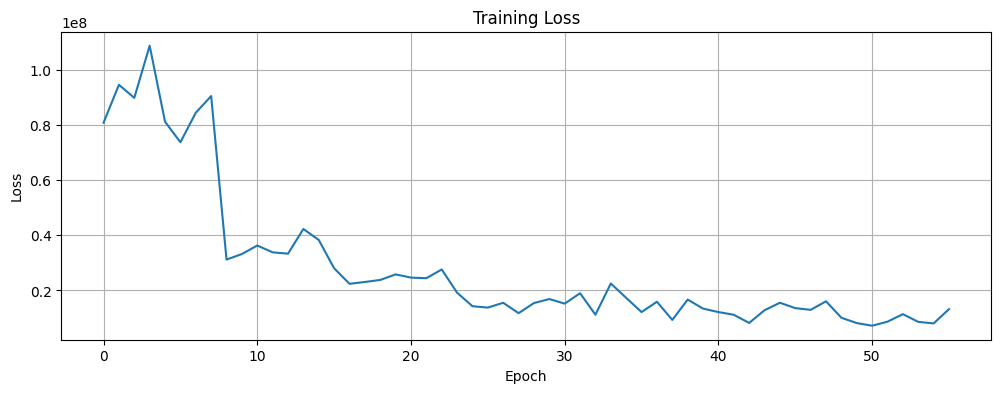

In [18]:
# Plot training curve
plt.figure(figsize=(12, 4))

plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
# plt.yscale('log')
plt.title('Training Loss')
plt.grid(True)

plt.show()

# Inference and testing

In [19]:
# model.load_state_dict(torch.load(MODEL_SAVE_PATH))

In [20]:
# visualize_results(model, dataset.map_paths[0], dataset.cat_paths[0], confidence_threshold=0.9)

shape of predictions:  (1, 1024, 1024)


/tmp/ipykernel_20650/727577447.py:104: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_auc = np.trapz(precisions, x=recalls)


PR-AUC Score: 0.6745


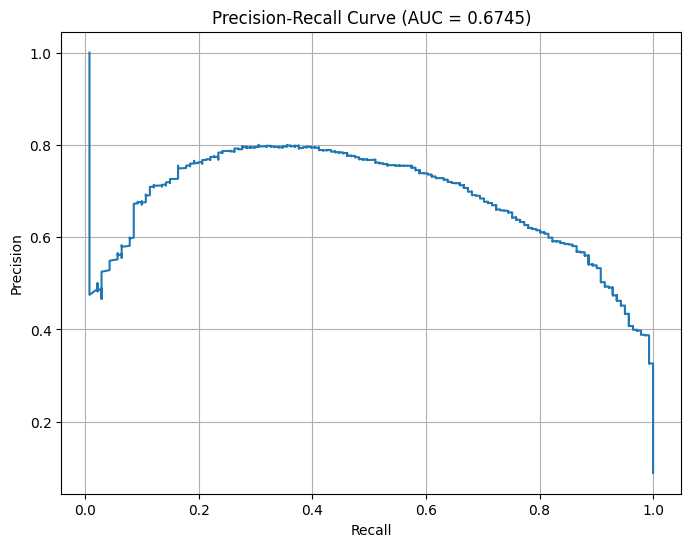

In [21]:
# Calculate PR-AUC
precisions, recalls, pr_auc = get_pr(model, test_dataloader)
print(f"PR-AUC Score: {pr_auc:.4f}")

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
plt.grid(True)
plt.show()

# Submission

In [22]:
if os.environ.get('DATA_PATH'):
    # Submit testA for public leaderboard 
    DATA_PATH = os.environ.get('DATA_PATH') + "/"
    TEST_DATA_DIR = DATA_PATH + 'halo_testA'
    test_size = len(os.listdir(os.path.join(TEST_DATA_DIR, 'map')))
    dataset = AstroDataset([os.path.join(TEST_DATA_DIR, f'map/{i}.fits') for i in range(1, test_size+1)])
    loader = DataLoader(dataset, batch_size=test_size, shuffle=False)
    model.eval()
    for images in loader:
        with torch.no_grad():
            outputs = model(images.to(DEVICE)).cpu().numpy().squeeze(1)
        np.save('submissionsA.npy', outputs)
    # Submit testB for private leaderboard
    TEST_DATA_DIR = DATA_PATH + 'halo_testB'
    test_size = len(os.listdir(os.path.join(TEST_DATA_DIR, 'map')))
    dataset = AstroDataset([os.path.join(TEST_DATA_DIR, f'map/{i}.fits') for i in range(1, test_size+1)])
    loader = DataLoader(dataset, batch_size=test_size, shuffle=False)
    model.eval()
    for images in loader:
        with torch.no_grad():
            outputs = model(images.to(DEVICE)).cpu().numpy().squeeze(1)
        np.save('submissionsB.npy', outputs)
    
    # The final submission will be a zip file containing the your model outputs for both testing sets
    with zipfile.ZipFile('submission.zip', 'w') as zipf:
        zipf.write('submissionsA.npy')
        zipf.write('submissionsB.npy')